<a href="https://colab.research.google.com/github/ebonyvan-web/capstone/blob/main/captone_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm

Birth Defect csv was saved as a file. Data location: https://www.health.ny.gov/statistics/environmental/public_health_tracking/about_pages/birth_defects/export

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('birth defect.csv')

# clean column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

df.head()

Saving birth defect.csv to birth defect (1).csv


,geography,datayears,anencephaly,anophthalmia_microphthalmia,anotia_microtia,aortic_valve_stenosis,atrial_septal_defect,atrioventricular_septal_defect__,biliary_atresia,bladder_exstrophy,...,tricuspid_valve_atresia,tricuspid_valve_atresia_and_sten,trisomy_13,trisomy_18,trisomy_21__down_syndrome_,turner_syndrome,ventricular_septal_defect,totalmalebirths,totalfemalebirths,totallivebirths
0,Albany,2000-2002,1,0,0,2,19,3,2,0,...,1,1,1,2,12,1,39,4951,4799,9750
1,Allegany,2000-2002,0,0,0,0,0,1,0,0,...,0,0,0,0,2,0,6,811,799,1610
2,Bronx,2000-2002,1,5,2,4,184,14,5,0,...,1,4,8,8,60,3,192,34858,33306,68165
3,Broome,2000-2002,0,0,0,4,35,1,1,0,...,0,0,0,1,8,0,40,3352,3068,6421
4,Cattaraugus,2000-2002,0,0,1,0,6,0,0,0,...,0,0,0,0,3,0,15,1576,1420,2998


Data Cleaning & Transformation

In [ ]:
# Rename columns to match project requirement
df = df.rename(columns={
    'geography': 'county',
    'datayears': 'year'
})

# Remove missing values
df = df.dropna()


# Convert data types
df['year'] = df['year'].astype(int)
df['births'] = df['births'].astype(int)
df['birth_defects'] = df['birth_defects'].astype(int)

# Create defect rate
df['defect_rate'] = df['birth_defects'] / df['births']


Explanation:
We cleaned the dataset, renamed columns, and created a defect rate to compare counties fairly.

County Analysis

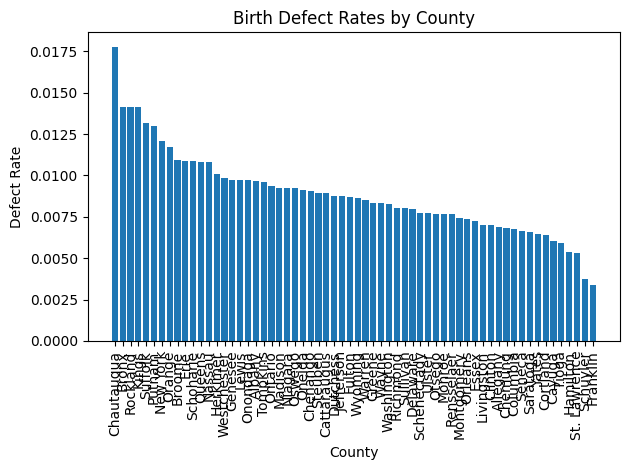

(        county  births  birth_defects  defect_rate
 6   Chautauqua   21449            381     0.017763
 2        Bronx  334169           4730     0.014155
 43    Rockland   68199            965     0.014150
 23       Kings  612099           8639     0.014114
 51     Suffolk  270738           3569     0.013182,
           county  births  birth_defects  defect_rate
 53         Tioga    7260             43     0.005923
 20      Hamilton     557              3     0.005386
 49  St. Lawrence   18298             97     0.005301
 47      Schuyler    2674             10     0.003740
 16      Franklin    7368             25     0.003393)

In [ ]:
county = analyze_defect_rates(df, 'county')

# sort highest to lowest
county = county.sort_values(by='defect_rate', ascending=False)

plt.figure()
plt.bar(county['county'], county['defect_rate'])
plt.xticks(rotation=90)
plt.title("Birth Defect Rates by County")
plt.xlabel("County")
plt.ylabel("Defect Rate")
plt.tight_layout()
plt.show()

county.head(), county.tail()

Counties with the Highest rates based on Year

In [ ]:
# Sort by defect_rate in descending order and display top counties
top_defect_rate_counties = df.sort_values(by='defect_rate', ascending=False)
display(top_defect_rate_counties[['county', 'year', 'defect_rate']].head(10))

,county,year,defect_rate
250,Bronx,2012,0.024079
130,Chautauqua,2006,0.022233
268,Hamilton,2012,0.021277
287,Putnam,2012,0.020782
188,Bronx,2009,0.018996
254,Chautauqua,2012,0.018944
68,Chautauqua,2003,0.018123
192,Chautauqua,2009,0.018022
291,Rockland,2012,0.017901
229,Rockland,2009,0.017484


Highest and Lowest

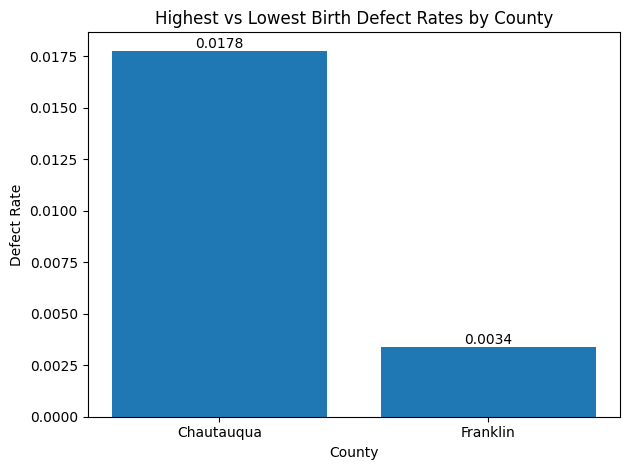

In [ ]:
import pandas as pd

plt.figure()

top_bottom = pd.DataFrame([highest, lowest])
bars = plt.bar(top_bottom['county'], top_bottom['defect_rate'])

# Add value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval,4),
             ha='center', va='bottom')

plt.title("Highest vs Lowest Birth Defect Rates by County")
plt.xlabel("County")
plt.ylabel("Defect Rate")

plt.tight_layout()
plt.show()

Highest vs Lowest County

In [ ]:
highest = county.iloc[0]
lowest = county.iloc[-1]

print("Highest County:\n", highest)
print("\nLowest County:\n", lowest)

Highest County:
 county           Chautauqua
births                21449
birth_defects           381
defect_rate        0.017763
Name: 6, dtype: object

Lowest County:
 county           Franklin
births               7368
birth_defects          25
defect_rate      0.003393
Name: 16, dtype: object


Trend Over Time

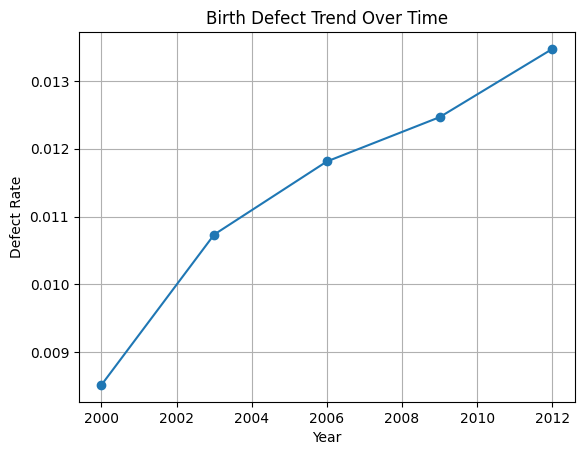

In [ ]:
trend = analyze_defect_rates(df, 'year')

plt.figure()
plt.plot(trend['year'], trend['defect_rate'], marker='o')
plt.title("Birth Defect Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Defect Rate")
plt.grid()
plt.show()